# Performance attribution and post-optimisation diagnostics

An optimiser hands you weights; it does not tell you whether the resulting book is any good.
Before trusting an allocation you analyse its *realised* behaviour: how wealth would have grown,
how deep and how long the drawdowns were, where the risk actually sits, and how much trading
costs eat into the result. None of these are objectives — they are **diagnostics you run after
`optimise`**, and they work on *any* weight vector, not just optimiser output (a benchmark, a
live book, an equal-weight sleeve).

Where the [plotting and reporting](02_Plotting_and_Reporting.md) page is a visual tour, this one
is the *quantitative* companion: the raw functions that return the numbers and series behind the
plots, so you can tabulate, compare, and attribute.

  - `cumulative_returns` — the equity curve, simple (sum) or compounded (product).
  - `drawdowns` — the peak-to-trough path, from which max drawdown, average drawdown,
    and the Ulcer index follow.
  - `calc_net_returns` and `calc_fees` — realised returns and cost drag after
    fees, so you can attribute how much performance the trading costs consumed.
  - `risk_contribution` — where the portfolio's risk comes from, by asset.

> **When to reach for this**
>
> Reach for these after you have chosen a portfolio, to understand and compare candidates on
> realised path behaviour, risk concentration, and cost drag — rather than re-optimising.
> Because they take a plain weight vector, they are equally the tools for reporting on a
> benchmark or an externally-supplied book.

In [1]:
using PortfolioOptimisers, PrettyTables, DataFrames, Statistics

resfmt = (v, i, j) -> begin
    if j == 1
        return v
    else
        return isa(v, Number) ? "$(round(v * 100, digits = 3)) %" : v
    end
end;

## 1. Candidate books

We build three portfolios to compare: a minimum-variance and a maximum-ratio book from
`MeanRisk`, plus a naive equal-weight sleeve. The equal-weight book is just a vector —
it shows that every diagnostic below works on any weights, not only optimiser results.

In [2]:
using CSV, TimeSeries, Clarabel

X = TimeArray(CSV.File(joinpath(@__DIR__, "..", "SP500.csv.gz")); timestamp = :Date)[(end - 252):end]
rd = prices_to_returns(X)
pr = prior(EmpiricalPrior(), rd)
rf = 4.2 / 100 / 252

slv = Solver(; name = :clarabel, solver = Clarabel.Optimizer,
             settings = Dict("verbose" => false),
             check_sol = (; allow_local = true, allow_almost = true))

w_min = optimise(MeanRisk(; obj = MinimumRisk(), opt = JuMPOptimiser(; pe = pr, slv = slv))).w
w_ratio = optimise(MeanRisk(; obj = MaximumRatio(; rf = rf),
                            opt = JuMPOptimiser(; pe = pr, slv = slv))).w
w_ew = fill(inv(length(rd.nx)), length(rd.nx))

books = ["Min variance" => w_min, "Max ratio" => w_ratio, "Equal weight" => w_ew]
# Realised in-sample portfolio return series for each book.
port_ret = [name => rd.X * w for (name, w) in books]

3-element Vector{Pair{String, Vector{Float64}}}:
 "Min variance" => [0.002681322622345559, 0.001071896359129222, -0.0010914272485229117, 0.004544617536040382, 0.003364067029438743, 0.010241746052438855, -0.0005334075714816542, 0.010636902007922422, 0.002021481739649502, -0.0020684143227993764  …  0.0016026835814611745, -0.013295284199450388, -0.008357208547582715, 0.0014778555240847477, 0.0036899176302618644, 0.011666675299059069, -0.005956204640017665, 0.007175142095470192, 0.0033377454197505187, -0.008845799550049606]
    "Max ratio" => [-0.0017735403232562686, -0.00036634958009974317, -0.0020420244554863022, 0.015047999836559715, 0.01400142687798936, 0.020249124903598967, 0.007577814646386211, 0.01509227923849206, 0.014987394169298077, 0.00870691096785051  …  0.00570170979862795, -0.01461959772475924, -0.004974247025468063, 0.0029772392002589392, 0.006541120023316683, 0.012794339416953043, -0.006090599666937747, 0.012667870030001693, 0.006264546445565508, -0.011709263471352097]
 "Eq

## 2. Cumulative returns: the equity curve

`cumulative_returns` turns a return series into a wealth path. Its `compound` flag picks
the convention:

  - `compound = false` (the default) sums the returns: `cumsum(X)` — the *absolute* cumulative
    return, additive and easy to reason about for short horizons.
  - `compound = true` multiplies them: `cumprod(1 .+ X)` — the *relative* (geometric) wealth
    multiple, which is what an investor actually realises through reinvestment.

The dedicated `absolute_cumulative_returns` and `relative_cumulative_returns`
expose the two conventions directly. We report each book's final compounded wealth multiple.

In [3]:
final_wealth = [name => cumulative_returns(r, true)[end] for (name, r) in port_ret]
pretty_table(DataFrame(; book = first.(final_wealth),
                       Symbol("compounded wealth (×)") =>
                           [round(last(p); digits = 4) for p in final_wealth]);
             title = "Final compounded wealth multiple over the sample")

Final compounded wealth multiple over the sample
┌──────────────┬───────────────────────┐
│         book │ compounded wealth (×) │
│       String │               Float64 │
├──────────────┼───────────────────────┤
│ Min variance │                1.2015 │
│    Max ratio │                1.6234 │
│ Equal weight │                1.0166 │
└──────────────┴───────────────────────┘


## 3. Drawdown analytics

`drawdowns` returns the full peak-to-trough series (each point is the loss from the
running high). From it we derive the three headline drawdown statistics: the **maximum
drawdown** (worst single decline), the **average drawdown** (time-average depth), and the
**Ulcer index** (root-mean-square depth, which punishes long drawdowns more than shallow
spikes). We compute compounded drawdowns to match the geometric equity curve.

In [4]:
dd_stats = map(port_ret) do (name, r)
    dd = drawdowns(r, true)          # compounded drawdown series, ≤ 0
    return (name = name, max_dd = -minimum(dd), avg_dd = -mean(dd),
            ulcer = sqrt(mean(dd .^ 2)))
end
pretty_table(DataFrame(dd_stats); formatters = [resfmt], title = "Drawdown analytics")

              Drawdown analytics
┌──────────────┬──────────┬─────────┬─────────┐
│         name │   max_dd │  avg_dd │   ulcer │
│       String │  Float64 │ Float64 │ Float64 │
├──────────────┼──────────┼─────────┼─────────┤
│ Min variance │  9.027 % │ 2.749 % │ 3.621 % │
│    Max ratio │  9.537 % │  2.13 % │ 3.013 % │
│ Equal weight │ 14.712 % │ 5.118 % │ 6.369 % │
└──────────────┴──────────┴─────────┴─────────┘


## 4. A realised-performance scorecard

Putting the path statistics together gives the kind of scorecard you would report for a book:
annualised return and volatility, the annualised Sharpe ratio (net of the risk-free rate), the
maximum drawdown, and the Calmar ratio (annualised return over maximum drawdown). All are derived
from the realised return series — no re-optimisation.

In [5]:
scorecard = map(port_ret) do (name, r)
    ann_ret = mean(r) * 252
    ann_vol = std(r) * sqrt(252)
    sharpe = (mean(r) - rf) / std(r) * sqrt(252)
    max_dd = -minimum(drawdowns(r, true))
    return (book = name, ann_return = ann_ret, ann_vol = ann_vol, sharpe = sharpe,
            max_drawdown = max_dd, calmar = ann_ret / max_dd)
end
pretty_table(DataFrame(scorecard);
             formatters = [(v, i, j) -> (if j in (2, 3, 5)
                                             "$(round(v*100, digits=2)) %"
                                         elseif isa(v, Number)
                                             round(v; digits = 3)
                                         else
                                             v
                                         end)], title = "Realised-performance scorecard")

                      Realised-performance scorecard
┌──────────────┬────────────┬─────────┬─────────┬──────────────┬─────────┐
│         book │ ann_return │ ann_vol │  sharpe │ max_drawdown │  calmar │
│       String │    Float64 │ Float64 │ Float64 │      Float64 │ Float64 │
├──────────────┼────────────┼─────────┼─────────┼──────────────┼─────────┤
│ Min variance │    19.46 % │ 14.83 % │   1.028 │       9.03 % │   2.155 │
│    Max ratio │    50.35 % │ 19.31 % │    2.39 │       9.54 % │    5.28 │
│ Equal weight │     3.71 % │ 20.36 % │  -0.024 │      14.71 % │   0.252 │
└──────────────┴────────────┴─────────┴─────────┴──────────────┴─────────┘


## 5. Cost attribution: gross vs net returns

A book that looks good gross can be mediocre net of trading costs. `calc_net_returns`
applies a `Fees` schedule to the realised returns; `calc_fees` reports the cost
of holding the weights for a *single* period.

The important subtlety is the time base: `calc_net_returns(w, X, fees)` deducts the fee on
**every row** of `X` — it models paying the rebalancing cost *each period*. So with 252 daily
observations a per-period fee of `l` accumulates to roughly `252 · l` over the year before
compounding. We therefore use a modest per-rebalance fee of 5 bps (`l = 0.0005`), which is about
a 12–13% annualised cost, and compare gross and net compounded wealth.

In [6]:
fees = Fees(; l = 0.0005)
gross_ret = rd.X * w_ratio
net_ret = calc_net_returns(w_ratio, rd.X, fees)
single_period_fee = calc_fees(w_ratio, fees)

pretty_table(DataFrame(;
                       quantity = ["Gross compounded wealth (×)",
                                   "Net compounded wealth (×)",
                                   "Single-period fee (fraction)",
                                   "Approx annualised fee (252 periods)"],
                       value = [round(cumulative_returns(gross_ret, true)[end]; digits = 4),
                                round(cumulative_returns(net_ret, true)[end]; digits = 4),
                                round(single_period_fee; digits = 5),
                                round(252 * single_period_fee; digits = 4)]);
             title = "Fee drag on the maximum-ratio book (5 bps per rebalance)")

Fee drag on the maximum-ratio book (5 bps per rebalance)
┌─────────────────────────────────────┬─────────┐
│                            quantity │   value │
│                              String │ Float64 │
├─────────────────────────────────────┼─────────┤
│         Gross compounded wealth (×) │  1.6234 │
│           Net compounded wealth (×) │  1.4315 │
│        Single-period fee (fraction) │  0.0005 │
│ Approx annualised fee (252 periods) │   0.126 │
└─────────────────────────────────────┴─────────┘


## 6. Risk attribution

A book can look diversified by *weight* yet be concentrated in *risk*. `risk_contribution`
decomposes the total risk into per-asset shares. As with the plotting layer, a quadratic risk
measure must be configured for the data — pass `factory(Variance(), pr)`, not a bare `Variance()`.
We normalise the contributions so they sum to one and report the largest for the minimum-variance
book.

In [7]:
rc = risk_contribution(factory(Variance(), pr), w_min, rd.X)
rc ./= sum(rc)
rc_df = sort(DataFrame(; asset = rd.nx, weight = w_min, risk_share = rc), :risk_share;
             rev = true)
pretty_table(first(rc_df, 8); formatters = [resfmt],
             title = "Top risk contributors — minimum-variance book")

Top risk contributors — minimum-variance book
┌────────┬──────────┬────────────┐
│  asset │   weight │ risk_share │
│ String │  Float64 │    Float64 │
├────────┼──────────┼────────────┤
│    JNJ │ 36.974 % │   36.972 % │
│    MRK │ 17.467 % │   17.467 % │
│     KO │ 11.161 % │   11.163 % │
│    WMT │  9.355 % │    9.355 % │
│    PEP │  8.978 % │    8.978 % │
│    CVX │  7.432 % │    7.434 % │
│    XOM │  4.725 % │    4.725 % │
│     PG │  2.353 % │    2.352 % │
└────────┴──────────┴────────────┘


The weight and risk shares are not the same: a low-weight, high-volatility or
highly-correlated name can carry a disproportionate share of the risk. That gap is exactly what
risk attribution surfaces.

## 7. The equity curves

Finally, the compounded wealth paths of the three books side by side — the visual summary of
everything the scorecard quantified.

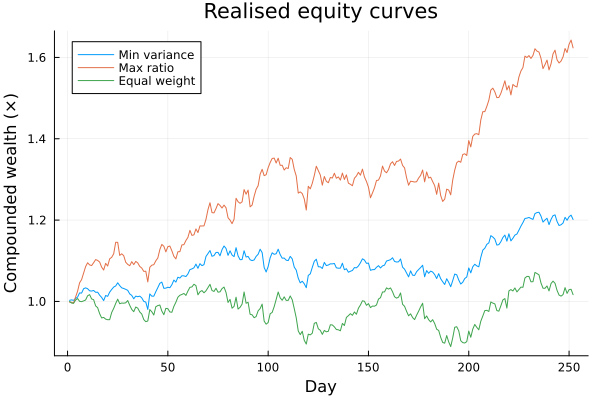

In [8]:
using StatsPlots, GraphRecipes
curves = [name => cumulative_returns(r, true) for (name, r) in port_ret]
plot(cumulative_returns(port_ret[1][2], true); label = first(port_ret[1]), xlabel = "Day",
     ylabel = "Compounded wealth (×)", title = "Realised equity curves", legend = :topleft)
for (name, r) in port_ret[2:end]
    plot!(cumulative_returns(r, true); label = name)
end
current()

## Summary

After the optimiser runs, the post-processing toolkit answers "how did this book actually
behave?" without any re-optimisation:

  - `cumulative_returns` (simple/compounded) is the equity curve;
    `drawdowns` gives the loss path and the max-drawdown / Ulcer statistics.
  - `calc_net_returns` and `calc_fees` attribute the cost drag, separating gross
    from net performance.
  - `risk_contribution` shows where the risk lives, which weight alone hides.

Every one of these takes a plain weight vector, so the same diagnostics report on optimiser
output, a benchmark, or any externally-supplied portfolio.

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*